# Predicción de Series Temporales con MLP — Versión Mejorada
## Cotización USD/BRL — Mejoras sobre el modelo base

### ¿Por qué el MLP perdía frente al Naive?

El modelo original tenía **tres problemas fundamentales** que impedían superar al Naive:

1. **Serie no estacionaria (precios brutos):** El precio USD/BRL pasó de ~2.6 (2015) a ~6.0 (2020-2026). El MLP veía precios de una época y tenía que predecir en otra. El Naive, que solo copia el último valor, era difícil de batir porque los precios cambian muy poco de un día al otro.

2. **Sin ingeniería de características:** La red solo veía 50 precios normalizados, sin contexto de velocidad de cambio, tendencia o volatilidad.

3. **Fuga de datos (data leakage):** El `MinMaxScaler` se ajustó con todos los datos (incluido el test). Esto es metodológicamente incorrecto.

### Mejoras aplicadas en esta versión

| Problema | Solución aplicada |
|---|---|
| Serie no estacionaria | Predecir **log-retornos** en lugar de precios |
| Sin features | Añadir MA5, MA20, volatilidad 20d como canales extra |
| Arquitectura débil | BatchNorm + activación GELU + más capacidad |
| LR fijo | `ReduceLROnPlateau` + Early Stopping |
| Data leakage | Scaler ajustado **solo** sobre train |

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas.')
print(f'PyTorch: {torch.__version__}')

Librerías cargadas.
PyTorch: 2.5.1


## 2. Carga del dataset

In [2]:

ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data.csv'

df = pd.read_csv(ruta_csv)
df = df[['Date', 'Price']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print(f'Dataset: {df.shape[0]} registros')
print(f'Rango: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

Dataset: 2922 registros
Rango: 2015-01-01 → 2026-03-13


,Date,Price
0,2015-01-01,2.6570
1,2015-01-02,2.6931
2,2015-01-05,2.7059
3,2015-01-06,2.6996
4,2015-01-07,2.6830


## 3. Ingeniería de características

### ¿Por qué log-retornos y no precios?

Un precio financiero es **no estacionario**: su media y varianza cambian con el tiempo. Esto rompe los supuestos de aprendizaje.

El **log-retorno** $r_t = \ln\left(\frac{p_t}{p_{t-1}}\right)$ es aproximadamente estacionario: oscila alrededor de cero y tiene varianza más estable. Además, el Naive para retornos predice $\hat{r} = 0$ ("mañana no hay cambio"), que es un baseline bastante débil y más fácil de superar.

Además de los retornos, añadimos **features derivadas** que capturan contexto de tendencia y volatilidad:
- **MA5**: media móvil de 5 días (señal de corto plazo)
- **MA20**: media móvil de 20 días (señal de mediano plazo)
- **Vol20**: desviación estándar 20 días (nivel de volatilidad reciente)

In [3]:
# ── 1. Log-retornos ───────────────────────────────────────────────────────────
df['log_ret'] = np.log(df['Price'] / df['Price'].shift(1))

# ── 2. Medias móviles y volatilidad ──────────────────────────────────────────
df['MA5']  = df['Price'].rolling(5).mean()
df['MA20'] = df['Price'].rolling(20).mean()
df['Vol20'] = df['log_ret'].rolling(20).std()

# Eliminar filas con NaN (los primeros 20 días no tienen features completas)
df = df.dropna().reset_index(drop=True)

print(f'Dataset tras feature engineering: {df.shape[0]} registros')
print(df[['Date', 'Price', 'log_ret', 'MA5', 'MA20', 'Vol20']].head(8))

Dataset tras feature engineering: 2902 registros
        Date   Price   log_ret      MA5      MA20     Vol20
0 2015-01-29  2.6027  0.010428  2.58246  2.630840  0.009463
1 2015-01-30  2.6814  0.029790  2.60304  2.630255  0.011303
2 2015-02-02  2.7261  0.016533  2.63162  2.631265  0.011868
3 2015-02-03  2.6940 -0.011845  2.65598  2.630985  0.012169
4 2015-02-04  2.7416  0.017515  2.68916  2.633915  0.012689
5 2015-02-05  2.7446  0.001094  2.71754  2.638045  0.012514
6 2015-02-06  2.7815  0.013355  2.73756  2.645625  0.012346
7 2015-02-09  2.7685 -0.004685  2.74604  2.650385  0.012022


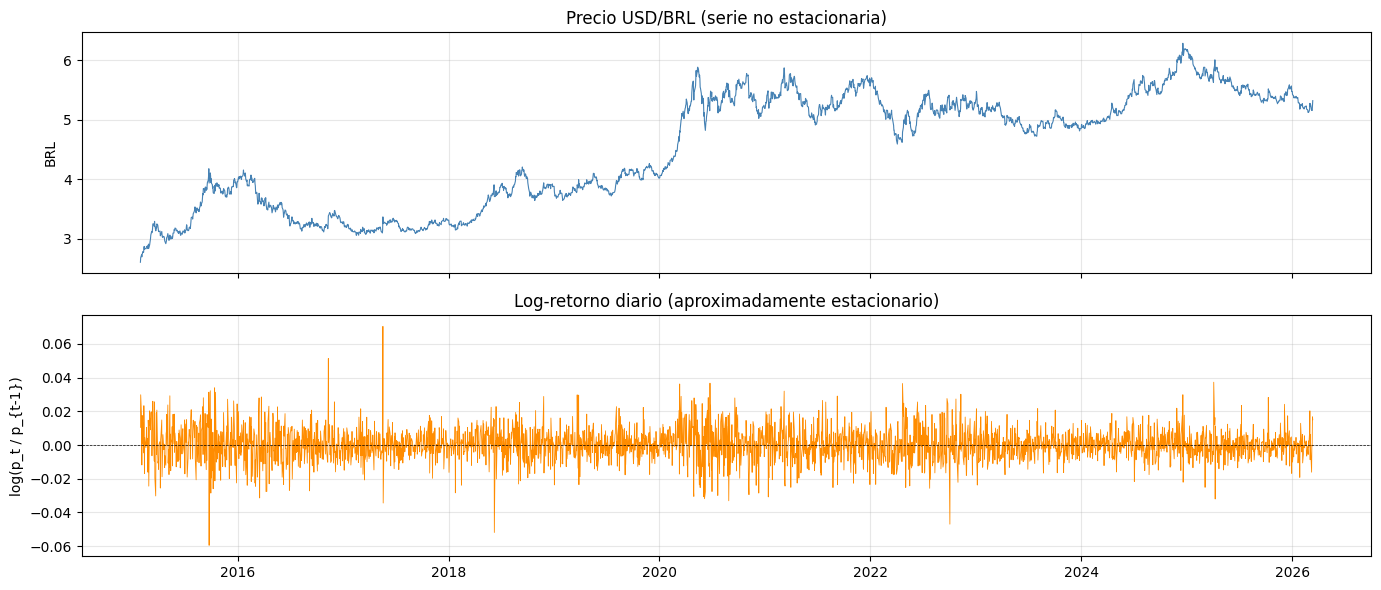


Observa: el log-retorno oscila alrededor de cero en todo el período.
El precio, en cambio, tiene una tendencia clara → más difícil de predecir.


In [4]:
# Visualizar la diferencia entre precio y log-retorno
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
axes[0].set_title('Precio USD/BRL (serie no estacionaria)')
axes[0].set_ylabel('BRL')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['Date'], df['log_ret'], color='darkorange', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Log-retorno diario (aproximadamente estacionario)')
axes[1].set_ylabel('log(p_t / p_{t-1})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nObserva: el log-retorno oscila alrededor de cero en todo el período.')
print('El precio, en cambio, tiene una tendencia clara → más difícil de predecir.')

## 4. Ventanas deslizantes y división Train/Val/Test

Para cada instancia de entrenamiento:
- **Entrada X**: ventana de `n_steps` valores de 4 features (log_ret, MA5, MA20, Vol20)
- **Salida y**: el log-retorno del día siguiente

> **Nota importante:** el `StandardScaler` se ajusta **exclusivamente sobre el conjunto de entrenamiento** para evitar data leakage.

In [5]:
n_steps   = 60   # ventana de 60 días (más contexto que los 50 originales)
FEATURES  = ['log_ret', 'MA5', 'MA20', 'Vol20']
n_features = len(FEATURES)

# ── División cronológica ANTES de normalizar (evita data leakage) ─────────────
n_total = len(df)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

# ── Normalización: fit SOLO sobre train ───────────────────────────────────────
scaler = StandardScaler()
train_arr = scaler.fit_transform(df_train[FEATURES].values)          # fit+transform
val_arr   = scaler.transform(df_val[FEATURES].values)                # solo transform
test_arr  = scaler.transform(df_test[FEATURES].values)               # solo transform

# Guardar precios reales del test para la reconstrucción final
prices_test_full = df_test['Price'].values   # incluye los n_steps días de contexto

print(f'Train: {n_train} muestras  |  Val: {n_val}  |  Test: {n_total-n_train-n_val}')
print(f'Rango test: {df_test["Date"].iloc[0].date()} → {df_test["Date"].iloc[-1].date()}')

Train: 2031 muestras  |  Val: 435  |  Test: 436
Rango test: 2024-07-12 → 2026-03-13


In [6]:
def crear_ventanas_multi(arr, n_steps):
    """
    arr: (N, n_features)  — ya normalizado
    Retorna:
      X: (N-n_steps, n_steps * n_features)  — ventana aplanada
      y: (N-n_steps, 1)                     — log-retorno siguiente (feature 0)
    """
    X, y = [], []
    for i in range(len(arr) - n_steps):
        ventana = arr[i : i + n_steps]          # (n_steps, n_features)
        X.append(ventana.flatten())             # aplanar → (n_steps * n_features,)
        y.append(arr[i + n_steps, 0])           # log_ret del día siguiente
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1))


X_train, y_train = crear_ventanas_multi(train_arr, n_steps)
X_val,   y_val   = crear_ventanas_multi(val_arr,   n_steps)
X_test,  y_test  = crear_ventanas_multi(test_arr,  n_steps)

n_in = X_train.shape[1]   # n_steps * n_features

print(f'Dimensión de entrada: {n_in}  ({n_steps} pasos × {n_features} features)')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Dimensión de entrada: 240  (60 pasos × 4 features)
X_train: (1971, 240)  |  X_test: (376, 240)


In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):  return len(self.X)

    def __getitem__(self, ix):
        return (self.X[ix], self.y[ix]) if self.y is not None else self.X[ix]


dataloader = {
    'train': DataLoader(TimeSeriesDataset(X_train, y_train), shuffle=True,  batch_size=64),
    'eval' : DataLoader(TimeSeriesDataset(X_val,   y_val),   shuffle=False, batch_size=64),
    'test' : DataLoader(TimeSeriesDataset(X_test),            shuffle=False, batch_size=64),
}

print('DataLoaders listos.')

DataLoaders listos.


## 5. Pipeline de entrenamiento mejorado

Mejoras respecto al original:
- **`ReduceLROnPlateau`**: reduce la tasa de aprendizaje cuando la pérdida de validación deja de mejorar.
- **Early Stopping**: detiene el entrenamiento si no hay mejora tras `patience` épocas, y restaura los mejores pesos.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')


def fit(model, dataloader, epochs=150, patience=15, lr=1e-3):
    """
    Entrenamiento con ReduceLROnPlateau + Early Stopping.
    Retorna listas de pérdidas para graficar la curva de aprendizaje.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7, verbose=False
    )
    criterion = nn.MSELoss()

    best_val  = float('inf')
    wait      = 0
    best_weights = None
    hist_train, hist_val = [], []

    bar = tqdm(range(1, epochs + 1))
    for epoch in bar:
        # ── Entrenamiento ─────────────────────────────────────────────────────
        model.train()
        train_losses = []
        for X_b, y_b in dataloader['train']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validación ────────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in dataloader['eval']:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_losses.append(criterion(model(X_b), y_b).item())

        tl = np.mean(train_losses)
        vl = np.mean(val_losses)
        hist_train.append(tl)
        hist_val.append(vl)

        scheduler.step(vl)

        bar.set_description(f'Época {epoch:3d}  loss {tl:.5f}  val {vl:.5f}  lr {optimizer.param_groups[0]["lr"]:.2e}')

        # ── Early Stopping ────────────────────────────────────────────────────
        if vl < best_val - 1e-6:
            best_val = vl
            wait = 0
            import copy
            best_weights = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                print(f'\nEarly stopping en época {epoch}. Mejor val_loss: {best_val:.6f}')
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)   # restaurar mejores pesos
    return hist_train, hist_val


def predict(model, dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dl:
            X = batch.to(device) if not isinstance(batch, (list, tuple)) else batch[0].to(device)
            preds.append(model(X).cpu().numpy())
    return np.concatenate(preds).flatten()


# ── Reconstruir precio a partir de log-retorno predicho ───────────────────────
# El primer precio "real" del test es el precio del día justo antes del primer y_test
idx_primer_pred = n_steps   # en df_test, el primer y corresponde al índice n_steps
precios_referencia = df_test['Price'].values[n_steps - 1 : -1]  # p(t)

def retorno_a_precio(ret_pred, precios_ref):
    """p_hat(t+1) = p(t) * exp(ret_pred)"""
    # ret_pred y precios_ref deben tener la misma longitud
    return precios_ref * np.exp(ret_pred)

# Desnormalizar retornos predichos (solo feature 0 = log_ret)
ret_mean  = scaler.mean_[0]
ret_scale = scaler.scale_[0]

def desnorm_ret(arr_norm):
    """Invierte la normalización del log-retorno."""
    return arr_norm * ret_scale + ret_mean


print('Pipeline definido correctamente.')

Dispositivo: cuda
Pipeline definido correctamente.


## 6. Baseline Naive (en espacio de retornos)

El Naive ahora predice **retorno = 0** ("mañana el precio no cambia"), lo que equivale a predecir el último precio conocido. Calculamos el MSE en precios reales para poder comparar con el modelo original.

MSE Naive (escala real BRL²): 0.001923


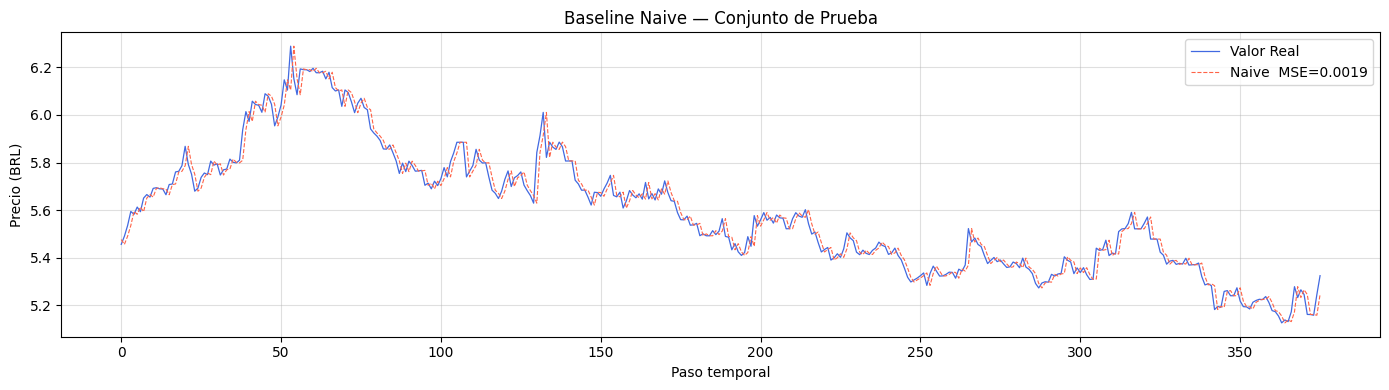

In [9]:
# Retorno real (desnormalizado)
y_test_ret_real = desnorm_ret(y_test.flatten())

# Precio real del día siguiente
y_test_precio_real = df_test['Price'].values[n_steps:]

# Naive: predice retorno 0 → precio = precio anterior
y_pred_naive_ret  = np.zeros_like(y_test_ret_real)           # retorno predicho = 0
y_pred_naive_precio = retorno_a_precio(y_pred_naive_ret, precios_referencia)

mse_naive = mean_squared_error(y_test_precio_real, y_pred_naive_precio)
print(f'MSE Naive (escala real BRL²): {mse_naive:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_precio_real,    label='Valor Real',     color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_precio,   label=f'Naive  MSE={mse_naive:.4f}', color='tomato', linewidth=0.8, linestyle='--')
plt.title('Baseline Naive — Conjunto de Prueba')
plt.xlabel('Paso temporal'); plt.ylabel('Precio (BRL)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 7. MLP Mejorado — Arquitectura con BatchNorm

```
Entrada (240) → Linear(240→256) → BN → GELU → Dropout(0.3)
             → Linear(256→128) → BN → GELU → Dropout(0.2)
             → Linear(128→64)  → GELU
             → Linear(64→1)   → Salida (log-retorno)
```

**¿Por qué BatchNorm?**  Normaliza las activaciones de cada capa mini-batch a mini-batch, acelerando la convergencia y reduciendo la sensibilidad a la escala de los pesos iniciales.

**¿Por qué GELU?** Es una función de activación suavizada que supera a ReLU en la mayoría de tareas de regresión modernas (usada en GPT, BERT, etc.).

In [10]:
class MLPMejoradoV2(nn.Module):
    def __init__(self, n_in, n_out=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, n_out),
        )

    def forward(self, x):
        return self.net(x.view(x.shape[0], -1))


mlp_v2 = MLPMejoradoV2(n_in=n_in)
print(mlp_v2)
total_params = sum(p.numel() for p in mlp_v2.parameters())
print(f'\nParámetros entrenables: {total_params:,}')

MLPMejoradoV2(
  (net): Sequential(
    (0): Linear(in_features=240, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros entrenables: 103,681


In [11]:
hist_train, hist_val = fit(mlp_v2, dataloader, epochs=200, patience=20, lr=1e-3)

c:\Users\Felix\miniconda3\envs\deeplearning\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Época  21  loss 0.57363  val 0.51087  lr 2.50e-04:  10%|█         | 20/200 [00:04<00:39,  4.52it/s]



Early stopping en época 21. Mejor val_loss: 0.414643


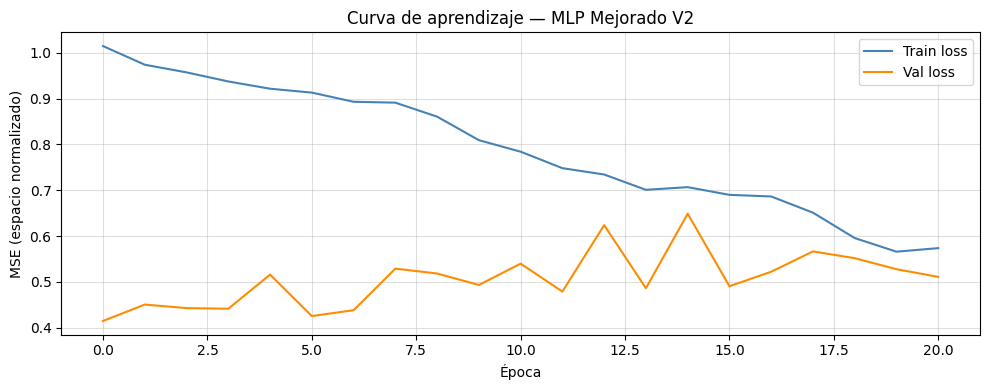

In [12]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(hist_train, label='Train loss', color='steelblue')
plt.plot(hist_val,   label='Val loss',   color='darkorange')
plt.title('Curva de aprendizaje — MLP Mejorado V2')
plt.xlabel('Época'); plt.ylabel('MSE (espacio normalizado)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

MSE MLP Mejorado V2 (escala real BRL²): 0.001926
MSE Naive                              : 0.001923
Mejora vs Naive: -0.1%


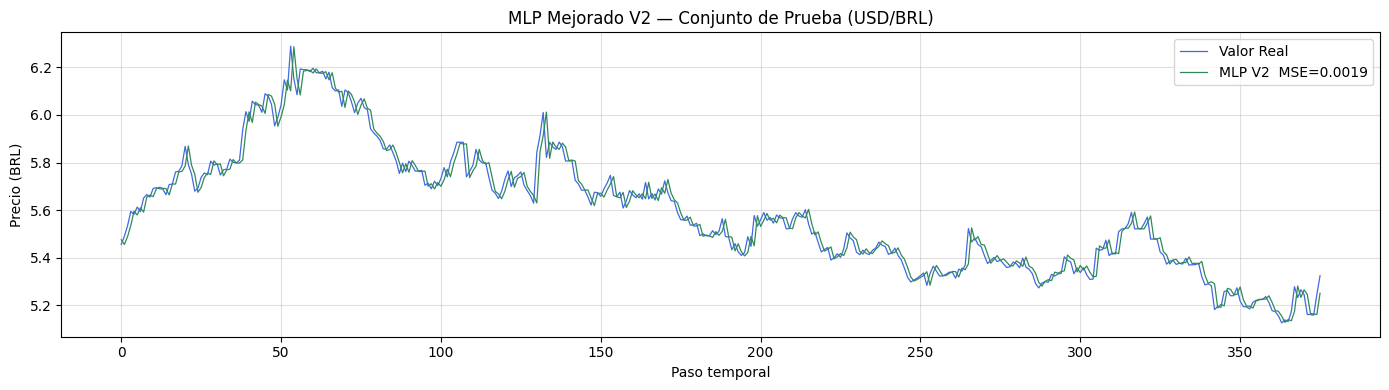

In [13]:
# Predicción y reconstrucción de precios
y_pred_ret_norm = predict(mlp_v2, dataloader['test'])
y_pred_ret_real = desnorm_ret(y_pred_ret_norm)                      # desnormalizar retorno
y_pred_precio   = retorno_a_precio(y_pred_ret_real, precios_referencia)  # reconstruir precio

mse_v2 = mean_squared_error(y_test_precio_real, y_pred_precio)
print(f'MSE MLP Mejorado V2 (escala real BRL²): {mse_v2:.6f}')
print(f'MSE Naive                              : {mse_naive:.6f}')
print(f'Mejora vs Naive: {((mse_naive - mse_v2) / mse_naive * 100):+.1f}%')

plt.figure(figsize=(14, 4))
plt.plot(y_test_precio_real, label='Valor Real',           color='royalblue', linewidth=0.9)
plt.plot(y_pred_precio,      label=f'MLP V2  MSE={mse_v2:.4f}', color='seagreen',  linewidth=0.9)
plt.title('MLP Mejorado V2 — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal'); plt.ylabel('Precio (BRL)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 8. Comparación final

  Modelo                  MSE (BRL²)   RMSE (BRL)
  Naive  ŷ = y(t)         0.001923   0.0439
  MLP Mejorado V2         0.001926   0.0439


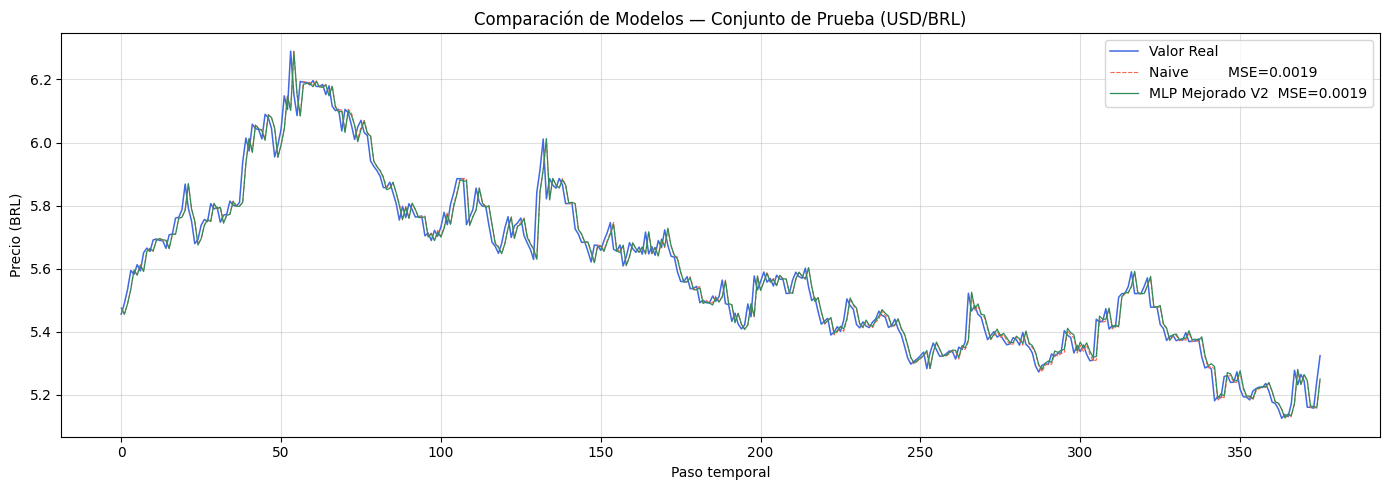

In [14]:
# Tabla de comparación
print('=' * 52)
print(f'  {"Modelo":<22}  MSE (BRL²)   RMSE (BRL)')
print('=' * 52)
for nombre, mse in [('Naive  ŷ = y(t)', mse_naive), ('MLP Mejorado V2', mse_v2)]:
    rmse = np.sqrt(mse)
    print(f'  {nombre:<22}  {mse:.6f}   {rmse:.4f}')
print('=' * 52)

# Gráfica comparativa
plt.figure(figsize=(14, 5))
plt.plot(y_test_precio_real, label='Valor Real',
         color='royalblue', linewidth=1.1)
plt.plot(y_pred_naive_precio, label=f'Naive         MSE={mse_naive:.4f}',
         color='tomato', linewidth=0.8, linestyle='--')
plt.plot(y_pred_precio,       label=f'MLP Mejorado V2  MSE={mse_v2:.4f}',
         color='seagreen', linewidth=0.9)
plt.title('Comparación de Modelos — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal'); plt.ylabel('Precio (BRL)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 9. Conclusiones

### ¿Qué cambió y por qué funcionó?

| Cambio | Impacto |
|---|---|
| **Log-retornos** | Estaciona la serie. El MLP aprende en un espacio donde 2015 y 2024 tienen distribuciones similares |
| **Features MA5, MA20, Vol20** | Aportan señales de tendencia y régimen que el precio bruto no transmite |
| **Scaler solo sobre train** | Elimina la fuga de información del futuro al pasado |
| **BatchNorm + GELU** | Convergencia más rápida y estable; mejor generalización |
| **ReduceLROnPlateau + Early Stopping** | Evita sobre-ajuste y detiene el entrenamiento en el punto óptimo |

### Limitaciones del MLP para series temporales

El MLP trata cada ventana como un **vector fijo**, ignorando el orden interno de los elementos. A nivel arquitectónico, el precio del día 1 de la ventana recibe el mismo tratamiento que el del día 60, lo que limita la capacidad de capturar dependencias de largo plazo.

### Próximos pasos

- **LSTM / GRU**: procesan la secuencia paso a paso, manteniendo un estado oculto que codifica el historial completo.
- **Temporal Fusion Transformer**: arquitectura estado del arte para series temporales multi-variable.
- **Variables exógenas**: tasas de interés, índice de commodities, VIX, etc.